<a href="https://colab.research.google.com/github/basil-abo6/Sleepstages-classification/blob/main/Sleepstages_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne scipy scikit-learn tqdm -q

import os, glob, re, math, time, gc
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from collections import Counter
from scipy import signal as scipy_signal
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, ConfusionMatrixDisplay)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import mne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
Device: cuda


2-**Mount Drive and set your dataset paths**





In [ ]:

from google.colab import drive
drive.mount('/content/drive')


SIGNAL_DIR     = '/content/drive/MyDrive/signals dataset final/project/Signals'
ANNOTATION_DIR = '/content/drive/MyDrive/signals dataset final/project/Annotations'


edf_files = sorted(glob.glob(os.path.join(SIGNAL_DIR, '*.edf')))
xml_files = sorted(glob.glob(os.path.join(ANNOTATION_DIR, '*.xml')))

print(f"Found {len(edf_files)} EDF files")
print(f"Found {len(xml_files)} XML files")
print("\nFirst 3 EDF files:", [os.path.basename(f) for f in edf_files[:3]])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 10 EDF files
Found 10 XML files

First 3 EDF files: ['mesa-sleep-0001.edf', 'mesa-sleep-0002.edf', 'mesa-sleep-0006.edf']


**Channel names in the data set bold text**

In [ ]:

raw = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)
print(f"Duration    : {raw.times[-1]/3600:.2f} hours")
print(f"Sample rate : {raw.info['sfreq']} Hz")
print(f"\nAll channels:")
for i, ch in enumerate(raw.ch_names):
    print(f"  [{i:2d}] {ch}")

Duration    : 12.00 hours
Sample rate : 256.0 Hz

All channels:
  [ 0] EKG
  [ 1] EOG-L
  [ 2] EOG-R
  [ 3] EMG
  [ 4] EEG1
  [ 5] EEG2
  [ 6] EEG3
  [ 7] Pres
  [ 8] Flow
  [ 9] Snore
  [10] Thor
  [11] Abdo
  [12] Leg
  [13] Therm
  [14] Pos
  [15] EKG_Off
  [16] EOG-L_Off
  [17] EOG-R_Off
  [18] EMG_Off
  [19] EEG1_Off
  [20] EEG2_Off
  [21] EEG3_Off
  [22] Pleth
  [23] OxStatus
  [24] SpO2
  [25] HR
  [26] DHR


**4 — Parse sleep stage labels from one XML file**

In [ ]:

def parse_mesa_xml(xml_path):
    tree   = ET.parse(xml_path)
    root   = tree.getroot()
    events = []
    for event in root.iter('ScoredEvent'):
        if 'Stages' not in event.findtext('EventType', ''):
            continue
        concept  = event.findtext('EventConcept', '')
        start    = float(event.findtext('Start',    '0'))
        duration = float(event.findtext('Duration', '30'))
        if   'Wake'    in concept: stage = 0
        elif 'Stage 1' in concept: stage = 1
        elif 'Stage 2' in concept: stage = 2
        elif 'Stage 3' in concept: stage = 3
        elif 'Stage 4' in concept: stage = 3
        elif 'REM'     in concept: stage = 4
        else: continue
        events.append((start, duration, stage))
    return events

# Test
events = parse_mesa_xml(xml_files[0])
counts = Counter(e[2] for e in events)
print("Stage distribution:",
      {stage_names[k]: v for k, v in sorted(counts.items())})

Stage distribution: {'Wake': 61, 'N1': 81, 'N2': 88, 'N3': 10, 'REM': 19}


** 5 — Define which channels to use (non-contact signals) Load & preprocess (ECG only)**

In [ ]:


TARGET_FS = 100
EPOCH_SEC = 30
SPE       = TARGET_FS * EPOCH_SEC

def find_ecg_channel(ch_names):
    """
    Returns the channel named exactly 'EKG'.
    Will NOT match 'EKG_Off', 'EKG2', 'EKG_ref' etc.
    """
    for ch in ch_names:
        if ch.strip() == 'EKG':
            return ch

    print("  WARNING: 'EKG' not found. Available channels:")
    for c in ch_names:
        print(f"    '{c}'")
    return None

def load_subject_ecg(edf_path, xml_path):
    """
    Loads ONE subject, extracts EKG channel only.
    Returns X: (n_epochs, 1, 3000)   y: (n_epochs,)
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    except Exception as e:
        print(f"  Skip {os.path.basename(edf_path)}: {e}")
        return None, None

    ecg_ch = find_ecg_channel(raw.ch_names)
    if ecg_ch is None:
        print(f"  Skip {os.path.basename(edf_path)}: EKG not found")
        return None, None

    raw.pick_channels([ecg_ch])

    if raw.info['sfreq'] != TARGET_FS:
        raw.resample(TARGET_FS, verbose=False)


    sig  = raw.get_data()[0]
    b, a = scipy_signal.butter(4, [0.5, 40.0], btype='bandpass', fs=TARGET_FS)
    sig  = scipy_signal.filtfilt(b, a, sig)


    events          = parse_mesa_xml(xml_path)
    n_samples_total = len(sig)
    label_array     = np.full(n_samples_total, -1, dtype=np.int8)
    for (onset, duration, stage) in events:
        s = int(onset * TARGET_FS)
        e = min(int((onset + duration) * TARGET_FS), n_samples_total)
        label_array[s:e] = stage


    n_epochs       = n_samples_total // SPE
    X_list, y_list = [], []

    for ep in range(n_epochs):
        s, e   = ep * SPE, ep * SPE + SPE
        labels = label_array[s:e]
        if np.any(labels == -1):
            continue
        stage = int(np.bincount(labels.astype(np.uint8)).argmax())
        chunk = sig[s:e].astype(np.float32)
        chunk = (chunk - chunk.mean()) / (chunk.std() + 1e-8)
        X_list.append(chunk[np.newaxis, :])   # (1, 3000)
        y_list.append(stage)

    if not X_list:
        return None, None

    return np.stack(X_list), np.array(y_list, dtype=np.int64)



raw_test = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)
print("All channels in first file:")
for ch in raw_test.ch_names:
    print(f"  '{ch}'")

found = find_ecg_channel(raw_test.ch_names)
print(f"\nChannel selected: '{found}'")
print("EKG_Off would be selected:", found == 'EKG_Off')

X_one, y_one = load_subject_ecg(edf_files[0], xml_files[0])
if X_one is not None:
    print(f"\nTest subject: X={X_one.shape}  y={y_one.shape}")
    print("Stage counts:",
          {stage_names[k]: v
           for k, v in sorted(Counter(y_one.tolist()).items())})

All channels in first file:
  'EKG'
  'EOG-L'
  'EOG-R'
  'EMG'
  'EEG1'
  'EEG2'
  'EEG3'
  'Pres'
  'Flow'
  'Snore'
  'Thor'
  'Abdo'
  'Leg'
  'Therm'
  'Pos'
  'EKG_Off'
  'EOG-L_Off'
  'EOG-R_Off'
  'EMG_Off'
  'EEG1_Off'
  'EEG2_Off'
  'EEG3_Off'
  'Pleth'
  'OxStatus'
  'SpO2'
  'HR'
  'DHR'

Channel selected: 'EKG'
EKG_Off would be selected: False
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

Test subject: X=(1439, 1, 3000)  y=(1439,)
Stage counts: {'Wake': 752, 'N1': 135, 'N2': 455, 'N3': 19, 'REM': 78}


**6--Load all subjects in memory-safe chunks**

In [ ]:

import os
import re
import numpy as np
import glob
import gc
from tqdm import tqdm


SAVE_BASE = '/content/drive/MyDrive/MESA'


os.makedirs(SAVE_BASE, exist_ok=True)
print(f"✅ Saving chunks to: {SAVE_BASE}\n")


def get_subject_id(path):
    m = re.search(r'mesa-sleep-(\d+)', os.path.basename(path))
    return m.group(1) if m else None

edf_dict   = {get_subject_id(f): f for f in edf_files}
xml_dict   = {get_subject_id(f): f for f in xml_files}
common_ids = sorted(set(edf_dict) & set(xml_dict))

print(f"Subjects with both EDF + XML: {len(common_ids)}")

CHUNK_SIZE = 5

for chunk_start in range(0, len(common_ids), CHUNK_SIZE):
    chunk_ids = common_ids[chunk_start : chunk_start + CHUNK_SIZE]
    chunk_X, chunk_y = [], []

    for sid in tqdm(chunk_ids, desc=f"Chunk {chunk_start//CHUNK_SIZE + 1}"):
        X, y = load_subject_ecg(edf_dict[sid], xml_dict[sid])
        if X is not None:
            chunk_X.append(X)
            chunk_y.append(y)

    if chunk_X:
        X_chunk = np.concatenate(chunk_X, axis=0)
        y_chunk = np.concatenate(chunk_y, axis=0)

        np.save(f'{SAVE_BASE}/chunk_X_{chunk_start}.npy', X_chunk)
        np.save(f'{SAVE_BASE}/chunk_y_{chunk_start}.npy', y_chunk)

        print(f"  ✅ Saved chunk — {X_chunk.shape[0]} epochs")


    del chunk_X, chunk_y, X_chunk, y_chunk
    gc.collect()


print("\nMerging all chunks...")
X_all = np.concatenate([np.load(f) for f in sorted(glob.glob(f'{SAVE_BASE}/chunk_X_*.npy'))], axis=0)
y_all = np.concatenate([np.load(f) for f in sorted(glob.glob(f'{SAVE_BASE}/chunk_y_*.npy'))], axis=0)

np.save(f'{SAVE_BASE}/X_all_ecg.npy', X_all)
np.save(f'{SAVE_BASE}/y_all_ecg.npy', y_all)

print(f"\n✅ Final dataset saved!")
print(f"   X shape: {X_all.shape}   (expected: (N_epochs, 1, 3000))")
print(f"   y shape: {y_all.shape}")

✅ Saving chunks to: /content/drive/MyDrive/MESA

Subjects with both EDF + XML: 10


Chunk 1:   0%|          | 0/5 [00:00<?, ?it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Chunk 1:  20%|██        | 1/5 [03:22<13:30, 202.63s/it]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Chunk 2:  80%|████████  | 4/5 [03:23<00:48, 48.51s/it]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Chunk 2: 100%|██████████| 5/5 [04:17<00:00, 51.60s/it]


  ✅ Saved chunk — 6295 epochs

Merging all chunks...

✅ Final dataset saved!
   X shape: (12758, 1, 3000)   (expected: (N_epochs, 1, 3000))
   y shape: (12758,)


**7 — Visualize class distribution & apply SMOTE**

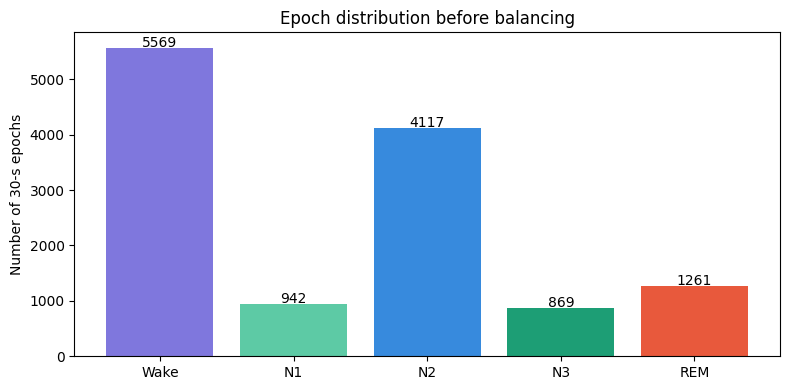

Class counts: {'Wake': 5569, 'N1': 942, 'N2': 4117, 'REM': 1261, 'N3': 869}


In [ ]:

from sklearn.model_selection import train_test_split
from collections import Counter



stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
counts = Counter(y_all)


fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stage_names, [counts[i] for i in range(5)],
              color=['#7F77DD','#5DCAA5','#378ADD','#1D9E75','#E8593C'])
ax.set_title('Epoch distribution before balancing')
ax.set_ylabel('Number of 30-s epochs')
for bar, cnt in zip(bars, [counts[i] for i in range(5)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(cnt), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Class counts:", {stage_names[k]: v for k, v in counts.items()})

**8--Split & class weights**

In [ ]:

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

print(f"Train : {len(y_train)} epochs")
print(f"Val   : {len(y_val)}   epochs")
print(f"Test  : {len(y_test)}  epochs")

class_weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(5), y=y_train)
print("\nBase class weights:",
      {stage_names[i]: f"{w:.2f}" for i, w in enumerate(class_weights)})


del X_all, y_all, X_temp, y_temp
gc.collect()
print("X_all freed from RAM.")

Train : 8935 epochs
Val   : 1909   epochs
Test  : 1914  epochs

Base class weights: {'Wake': '0.46', 'N1': '2.71', 'N2': '0.62', 'N3': '2.93', 'REM': '2.02'}
X_all freed from RAM.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


X_all = np.load(f'{SAVE_BASE}/X_all_ecg.npy')
y_all = np.load(f'{SAVE_BASE}/y_all_ecg.npy')
print(f"Reloaded: X={X_all.shape}  y={y_all.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)


class_weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(5), y=y_train)

print(f"Train : {len(y_train)}  Val : {len(y_val)}  Test : {len(y_test)}")


del X_all, y_all, X_temp, y_temp
gc.collect()
print("Ready.")

Reloaded: X=(12758, 1, 3000)  y=(12758,)
Train : 8935  Val : 1909  Test : 1914
Ready.


In [ ]:

class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.gamma        = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets,
                              weight=self.class_weights, reduction='none')
        pt  = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()



weights_tensor  = torch.FloatTensor(class_weights).to(device)
manual_boost    = torch.tensor([1.0, 5.0, 1.0, 3.5, 2.5]).to(device)

boosted_weights = weights_tensor * manual_boost
boosted_weights = boosted_weights / boosted_weights.mean()
criterion       = FocalLoss(class_weights=boosted_weights, gamma=2.5)


print("Boosted weights:")
for i, (n, w) in enumerate(zip(stage_names,
                                boosted_weights.cpu().numpy())):
    print(f"  {n}: {w:.3f}")



def augment_ecg(x):
    """x: (1, 3000)"""
    x   = x.copy()
    rng = np.random.default_rng()
    if rng.random() < 0.5:
        x += rng.normal(0, 0.05, x.shape).astype(np.float32)
    if rng.random() < 0.5:
        x *= rng.uniform(0.8, 1.2)
    if rng.random() < 0.4:
        t      = np.linspace(0, 1, x.shape[1])
        freq   = rng.uniform(0.05, 0.3)
        wander = (0.1 * np.sin(2 * np.pi * freq * t)).astype(np.float32)
        x[0]  += wander
    if rng.random() < 0.4:
        x = np.roll(x, rng.integers(-150, 150), axis=1)
    return x



def mixup_class(X, y, cls, n_samples, alpha=0.4):
    """
    Creates n_samples synthetic epochs for class cls
    by blending two real examples: x_new = λ*x1 + (1-λ)*x2
    alpha controls how uniform λ is (0.4 = moderate blending)
    """
    idx    = np.where(y == cls)[0]
    out_X  = []
    for _ in range(n_samples):
        i1, i2 = np.random.choice(idx, 2, replace=True)
        lam    = np.random.beta(alpha, alpha)
        mixed  = lam * X[i1] + (1 - lam) * X[i2]
        out_X.append(mixed.astype(np.float32))
    return np.stack(out_X)


def oversample_minority(X, y, target_ratio=0.70):
    counts     = Counter(y.tolist())
    target_cnt = int(max(counts.values()) * target_ratio)
    X_list, y_list = [X], [y]

    for cls in [1, 3, 4]:   # N1, N3, REM
        needed = target_cnt - counts.get(cls, 0)
        if needed <= 0:
            continue

        if cls == 1:

            n_aug   = needed // 2
            n_mix   = needed - n_aug

            idx     = np.where(y == cls)[0]
            aug_X   = np.stack([augment_ecg(X[np.random.choice(idx)])
                                 for _ in range(n_aug)])
            mix_X   = mixup_class(X, y, cls, n_mix, alpha=0.4)
            new_X   = np.concatenate([aug_X, mix_X], axis=0)
        else:

            idx     = np.where(y == cls)[0]
            new_X   = np.stack([augment_ecg(X[np.random.choice(idx)])
                                 for _ in range(needed)])

        print(f"  {stage_names[cls]}: "
              f"{counts[cls]} → {counts[cls] + needed} epochs")
        X_list.append(new_X)
        y_list.append(np.full(needed, cls, dtype=np.int64))

    X_out = np.concatenate(X_list, axis=0)
    y_out = np.concatenate(y_list, axis=0)
    perm  = np.random.permutation(len(y_out))
    return X_out[perm], y_out[perm]


print("\nOversampling N1 (aug+mixup), N3 and REM (aug)...")
X_train_aug, y_train_aug = oversample_minority(X_train, y_train)

print("\nFinal training distribution:")
for i, n in enumerate(stage_names):
    print(f"  {n}: {Counter(y_train_aug.tolist()).get(i, 0)}")


print("\nSaving to Drive...")
np.save(f'{SAVE_BASE}/X_train_aug.npy', X_train_aug)
np.save(f'{SAVE_BASE}/X_val.npy',       X_val)
np.save(f'{SAVE_BASE}/X_test.npy',      X_test)
np.save(f'{SAVE_BASE}/y_train_aug.npy', y_train_aug)
np.save(f'{SAVE_BASE}/y_val.npy',       y_val)
np.save(f'{SAVE_BASE}/y_test.npy',      y_test)
print("Saved.")

del X_train, y_train
gc.collect()

Boosted weights:
  Wake: 0.077
  N1: 2.260
  N2: 0.103
  N3: 1.715
  REM: 0.845

Oversampling N1 (aug+mixup), N3 and REM (aug)...
  N1: 660 → 2730 epochs
  N3: 609 → 2730 epochs
  REM: 883 → 2730 epochs

Final training distribution:
  Wake: 3900
  N1: 2730
  N2: 2883
  N3: 2730
  REM: 2730

Saving to Drive...
Saved.


60

In [ ]:




BANDS = [
    (0.04, 0.15),
    (0.15, 0.40),
    (0.5,  4.0),
    (4.0,  15.0),
    (15.0, 40.0),
]
BATCH_SIZE_SF = 300

def spectral_single_epoch(x, fs=TARGET_FS):
    """
    x   : (1, 3000)
    out : (5, 3000)  — one band-power trace per band
    """
    n_time = x.shape[1]
    out    = np.zeros((len(BANDS), n_time), dtype=np.float32)
    freqs, _, Zxx = stft(x[0], fs=fs, nperseg=256, noverlap=192)
    power = np.abs(Zxx) ** 2

    for bi, (flo, fhi) in enumerate(BANDS):
        mask    = (freqs >= flo) & (freqs <= fhi)
        if mask.sum() == 0:
            continue
        bp      = power[mask].mean(axis=0)
        bp_full = np.interp(np.linspace(0,1,n_time),
                            np.linspace(0,1,len(bp)), bp)
        bp_full = (bp_full - bp_full.mean()) / (bp_full.std() + 1e-8)
        out[bi] = bp_full

    return out

def process_spectral_memmap(X, split_name):
    """
    Writes (n_epochs, 6, 3000) directly to disk epoch by epoch.
    1 original ECG channel + 5 spectral band channels = 6 total.
    Peak RAM = one batch only.
    """
    n_epochs  = len(X)
    n_ch_out  = X.shape[1] + len(BANDS)   # 1 + 5 = 6
    shape     = (n_epochs, n_ch_out, SPE)
    out_path  = f'{SAVE_BASE}/X_{split_name}_sf.npy'
    n_batches = (n_epochs + BATCH_SIZE_SF - 1) // BATCH_SIZE_SF

    print(f"\n[{split_name}]  {n_epochs} epochs  "
          f"→  shape {shape}  ({n_batches} batches)")

    mmap = np.memmap(out_path, dtype='float32', mode='w+', shape=shape)

    for b in range(n_batches):
        s       = b * BATCH_SIZE_SF
        e       = min(s + BATCH_SIZE_SF, n_epochs)
        X_batch = X[s:e]
        tmp     = np.zeros((e-s, n_ch_out, SPE), dtype=np.float32)

        for i in range(e - s):
            sf     = spectral_single_epoch(X_batch[i])
            tmp[i] = np.concatenate([X_batch[i], sf], axis=0)

        mmap[s:e] = tmp
        del tmp, X_batch
        gc.collect()
        print(f"  batch {b+1:3d}/{n_batches}  rows {s}–{e-1}", flush=True)

    mmap.flush()
    del mmap
    gc.collect()
    print(f"  Saved: {out_path}")

process_spectral_memmap(X_train_aug, 'train')
process_spectral_memmap(X_val,       'val')
process_spectral_memmap(X_test,      'test')

# Save y arrays too
np.save(f'{SAVE_BASE}/y_train_aug.npy', y_train_aug)
np.save(f'{SAVE_BASE}/y_val.npy',       y_val)
np.save(f'{SAVE_BASE}/y_test.npy',      y_test)

del X_train_aug, X_val, X_test
gc.collect()
print("\nCell 10 complete. All arrays freed from RAM.")


[train]  14973 epochs  →  shape (14973, 6, 3000)  (50 batches)
  batch   1/50  rows 0–299
  batch   2/50  rows 300–599
  batch   3/50  rows 600–899
  batch   4/50  rows 900–1199
  batch   5/50  rows 1200–1499
  batch   6/50  rows 1500–1799
  batch   7/50  rows 1800–2099
  batch   8/50  rows 2100–2399
  batch   9/50  rows 2400–2699
  batch  10/50  rows 2700–2999
  batch  11/50  rows 3000–3299
  batch  12/50  rows 3300–3599
  batch  13/50  rows 3600–3899
  batch  14/50  rows 3900–4199
  batch  15/50  rows 4200–4499
  batch  16/50  rows 4500–4799
  batch  17/50  rows 4800–5099
  batch  18/50  rows 5100–5399
  batch  19/50  rows 5400–5699
  batch  20/50  rows 5700–5999
  batch  21/50  rows 6000–6299
  batch  22/50  rows 6300–6599
  batch  23/50  rows 6600–6899
  batch  24/50  rows 6900–7199
  batch  25/50  rows 7200–7499
  batch  26/50  rows 7500–7799
  batch  27/50  rows 7800–8099
  batch  28/50  rows 8100–8399
  batch  29/50  rows 8400–8699
  batch  30/50  rows 8700–8999
  batch  31/50 

In [ ]:


class ResidualBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels), nn.ELU(),
            nn.Dropout(0.1),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels))
        self.act = nn.ELU()
    def forward(self, x):
        return self.act(x + self.block(x))


class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        b = out_ch // 4
        self.b1 = nn.Sequential(
            nn.Conv1d(in_ch, b, 3,  padding=1),  nn.BatchNorm1d(b), nn.ELU())
        self.b2 = nn.Sequential(
            nn.Conv1d(in_ch, b, 9,  padding=4),  nn.BatchNorm1d(b), nn.ELU())
        self.b3 = nn.Sequential(
            nn.Conv1d(in_ch, b, 25, padding=12), nn.BatchNorm1d(b), nn.ELU())
        self.b4 = nn.Sequential(
            nn.MaxPool1d(3, stride=1, padding=1),
            nn.Conv1d(in_ch, b, 1), nn.BatchNorm1d(b), nn.ELU())
    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x),
                          self.b3(x), self.b4(x)], dim=1)


class EpochEncoder(nn.Module):
    def __init__(self, n_channels, d_model=256):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=50, stride=5, padding=25),
            nn.BatchNorm1d(64), nn.ELU(),
            nn.Dropout(0.15),
            nn.MaxPool1d(2))
        self.multi_scale = MultiScaleCNN(64, 128)
        self.res_blocks  = nn.Sequential(
            ResidualBlock1D(128, 7), ResidualBlock1D(128, 7),
            nn.Dropout(0.15),
            nn.MaxPool1d(2),
            ResidualBlock1D(128, 5), ResidualBlock1D(128, 5),
            nn.Dropout(0.15),
            nn.MaxPool1d(2))
        self.proj = nn.Sequential(
            nn.Conv1d(128, d_model, 1), nn.BatchNorm1d(d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=0.2,
            batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.attn_pool   = nn.Sequential(
            nn.Linear(d_model, 64), nn.Tanh(), nn.Linear(64, 1))

    def forward(self, x):
        x = self.input_proj(x)
        x = self.multi_scale(x)
        x = self.res_blocks(x)
        x = self.proj(x).permute(0, 2, 1)
        x = self.transformer(x)
        a = F.softmax(self.attn_pool(x).squeeze(-1), dim=1).unsqueeze(-1)
        return (x * a).sum(dim=1)


class SequenceSleepModel(nn.Module):
    SEQ_LEN = 9

    def __init__(self, n_channels, n_classes=5, d_model=256):
        super().__init__()
        self.half          = self.SEQ_LEN // 2
        self.epoch_encoder = EpochEncoder(n_channels, d_model)
        self.pos_embed     = nn.Embedding(self.SEQ_LEN, d_model)
        seq_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=0.3,
            batch_first=True, activation='gelu')
        self.seq_transformer = nn.TransformerEncoder(seq_layer, num_layers=2)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 256), nn.GELU(),
            nn.Dropout(0.55),
            nn.Linear(256, 128),     nn.GELU(),
            nn.Dropout(0.45),
            nn.Linear(128, n_classes))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_seq):
        B, S, C, T = x_seq.shape
        enc  = self.epoch_encoder(x_seq.view(B*S, C, T)).view(B, S, -1)
        pos  = torch.arange(S, device=x_seq.device)
        enc  = enc + self.pos_embed(pos)
        ctx  = self.seq_transformer(enc)
        return self.classifier(ctx[:, self.half, :])


print("Model classes defined with stronger regularization.")


Model classes defined with stronger regularization.


In [ ]:


SEQ_LEN = SequenceSleepModel.SEQ_LEN   # = 9


y_train_aug = np.load(f'{SAVE_BASE}/y_train_aug.npy')
y_val       = np.load(f'{SAVE_BASE}/y_val.npy')
y_test      = np.load(f'{SAVE_BASE}/y_test.npy')


def open_memmap(split_name, n_epochs):
    path       = f'{SAVE_BASE}/X_{split_name}_sf.npy'
    file_bytes = os.path.getsize(path)
    n_ch_out   = file_bytes // 4 // (n_epochs * SPE)
    shape      = (n_epochs, int(n_ch_out), SPE)
    print(f"  {split_name}: {shape}")
    return np.memmap(path, dtype='float32', mode='r', shape=shape)

X_train_sf = open_memmap('train', len(y_train_aug))
X_val_sf   = open_memmap('val',   len(y_val))
X_test_sf  = open_memmap('test',  len(y_test))

n_in = X_train_sf.shape[1]
print(f"\nInput channels: {n_in}  (1 ECG + 5 spectral bands)")


class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=SEQ_LEN):
        self.X    = X
        self.y    = y
        self.half = seq_len // 2
        self.slen = seq_len
    def __len__(self):
        return len(self.y) - self.slen + 1
    def __getitem__(self, idx):
        x = torch.FloatTensor(
                np.array(self.X[idx : idx + self.slen]))
        y = torch.tensor(int(self.y[idx + self.half]),
                         dtype=torch.long)
        return x, y

train_ds = SequenceDataset(X_train_sf, y_train_aug)
val_ds   = SequenceDataset(X_val_sf,   y_val)
test_ds  = SequenceDataset(X_test_sf,  y_test)

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)


model = SequenceSleepModel(n_channels=n_in).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel built successfully")
print(f"Parameters    : {total:,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

  train: (14973, 6, 3000)
  val: (1909, 6, 3000)
  test: (1914, 6, 3000)

Input channels: 6  (1 ECG + 5 spectral bands)

Model built successfully
Parameters    : 3,147,206
Train batches : 468
Val batches   : 60


In [ ]:


class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs,
                 total_epochs, base_lr, eta_min=1e-6):
        self.opt           = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.base_lr       = base_lr
        self.eta_min       = eta_min
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1
        ep = self.current_epoch
        if ep <= self.warmup_epochs:
            lr = self.base_lr * ep / self.warmup_epochs
        else:
            progress = ((ep - self.warmup_epochs) /
                        (self.total_epochs - self.warmup_epochs))
            lr = (self.eta_min + 0.5 * (self.base_lr - self.eta_min)
                  * (1 + math.cos(math.pi * progress)))
        for pg in self.opt.param_groups:
            pg['lr'] = lr
        return lr


EPOCHS    = 80
BASE_LR   = 8e-5
PATIENCE  = 20
SAVE_PATH = f'{SAVE_BASE}/best_model_ecg.pt'

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=1e-2,
    betas=(0.9, 0.999))

scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=8,
    total_epochs=EPOCHS,
    base_lr=BASE_LR)

print(f"AdamW  lr={BASE_LR}  weight_decay=1e-2")
print(f"Warmup=8 epochs  Max={EPOCHS}  Patience={PATIENCE}")

AdamW  lr=8e-05  weight_decay=1e-2
Warmup=8 epochs  Max=80  Patience=20


Ep 001  tr=25.1%  vl=11.8%  F1=9.8%  κ=0.049  lr=1.0e-05  (125s)
  ✓ Saved  κ=0.0487  acc=11.8%
Ep 002  tr=31.0%  vl=11.0%  F1=9.3%  κ=0.040  lr=2.0e-05  (129s)
Ep 003  tr=31.9%  vl=10.2%  F1=9.3%  κ=0.031  lr=3.0e-05  (130s)
Ep 004  tr=32.9%  vl=9.8%  F1=9.8%  κ=0.025  lr=4.0e-05  (130s)
Ep 005  tr=33.9%  vl=11.3%  F1=12.6%  κ=0.041  lr=5.0e-05  (130s)
Ep 006  tr=35.5%  vl=11.5%  F1=13.8%  κ=0.042  lr=6.0e-05  (130s)
Ep 007  tr=37.2%  vl=12.0%  F1=14.3%  κ=0.049  lr=7.0e-05  (130s)
  ✓ Saved  κ=0.0493  acc=12.0%
Ep 008  tr=37.9%  vl=12.5%  F1=15.9%  κ=0.053  lr=8.0e-05  (130s)
  ✓ Saved  κ=0.0530  acc=12.5%
Ep 009  tr=39.9%  vl=12.3%  F1=14.9%  κ=0.052  lr=8.0e-05  (130s)
Ep 010  tr=41.4%  vl=12.0%  F1=15.1%  κ=0.050  lr=8.0e-05  (130s)
Ep 011  tr=42.7%  vl=13.4%  F1=18.1%  κ=0.063  lr=8.0e-05  (131s)
  ✓ Saved  κ=0.0635  acc=13.4%
Ep 012  tr=44.0%  vl=12.7%  F1=15.8%  κ=0.057  lr=7.9e-05  (130s)
Ep 013  tr=45.3%  vl=13.8%  F1=18.9%  κ=0.068  lr=7.9e-05  (130s)
  ✓ Saved  κ=0.0683  ac

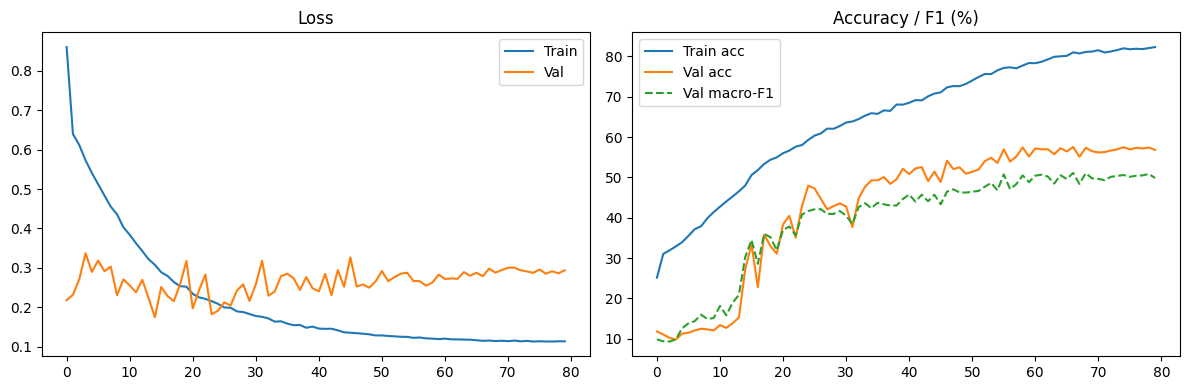


Best val kappa: 0.4161


In [ ]:

from sklearn.metrics import f1_score

best_kappa     = -1.0
patience_count = 0
train_hist, val_hist = [], []

for epoch in range(1, EPOCHS + 1):

    model.train()
    tr_loss = tr_correct = n_tr = 0
    t0 = time.time()

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)


        if np.random.random() < 0.2:
            X_b = X_b + torch.randn_like(X_b) * 0.02

        optimizer.zero_grad()
        logits     = model(X_b)
        focal      = criterion(logits, y_b)
        smooth     = F.cross_entropy(logits, y_b,
                                     weight=boosted_weights,
                                     label_smoothing=0.1)
        loss       = 0.7 * focal + 0.3 * smooth
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_loss    += loss.item() * len(y_b)
        tr_correct += (logits.argmax(1) == y_b).sum().item()
        n_tr       += len(y_b)


    model.eval()
    vl_loss = vl_correct = n_vl = 0
    vl_preds, vl_true = [], []

    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            preds    = logits.argmax(1)
            vl_loss    += loss.item() * len(y_b)
            vl_correct += (preds == y_b).sum().item()
            n_vl       += len(y_b)
            vl_preds.extend(preds.cpu().numpy())
            vl_true.extend(y_b.cpu().numpy())

    lr       = scheduler.step()
    tr_acc   = tr_correct / n_tr * 100
    vl_acc   = vl_correct / n_vl * 100
    vl_f1    = f1_score(vl_true, vl_preds,
                        average='macro', zero_division=0) * 100
    vl_kappa = cohen_kappa_score(vl_true, vl_preds)

    train_hist.append({'loss': tr_loss/n_tr, 'acc': tr_acc})
    val_hist.append({'loss': vl_loss/n_vl,
                     'acc': vl_acc, 'f1': vl_f1, 'kappa': vl_kappa})

    print(f"Ep {epoch:03d}  "
          f"tr={tr_acc:.1f}%  "
          f"vl={vl_acc:.1f}%  "
          f"F1={vl_f1:.1f}%  "
          f"κ={vl_kappa:.3f}  "
          f"lr={lr:.1e}  "
          f"({time.time()-t0:.0f}s)")

    # Save on best kappa
    if vl_kappa > best_kappa:
        best_kappa     = vl_kappa
        patience_count = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'kappa': best_kappa,
                    'val_acc': vl_acc}, SAVE_PATH)
        print(f"  ✓ Saved  κ={best_kappa:.4f}  acc={vl_acc:.1f}%")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot([h['loss'] for h in train_hist], label='Train')
ax1.plot([h['loss'] for h in val_hist],   label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot([h['acc'] for h in train_hist],  label='Train acc')
ax2.plot([h['acc'] for h in val_hist],    label='Val acc')
ax2.plot([h['f1']  for h in val_hist],    label='Val macro-F1',
         linestyle='--')
ax2.set_title('Accuracy / F1 (%)'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"\nBest val kappa: {best_kappa:.4f}")

Best model: epoch 45  κ=0.5933

Running on test set...
Running on val set...
Running on train set...

Test Accuracy : 72.25%
Cohen's Kappa : 0.5933

              precision    recall  f1-score   support

        Wake       0.91      0.88      0.89       830
          N1       0.35      0.31      0.33       141
          N2       0.64      0.72      0.68       616
          N3       0.55      0.55      0.55       130
         REM       0.58      0.49      0.53       189

    accuracy                           0.72      1906
   macro avg       0.61      0.59      0.60      1906
weighted avg       0.72      0.72      0.72      1906



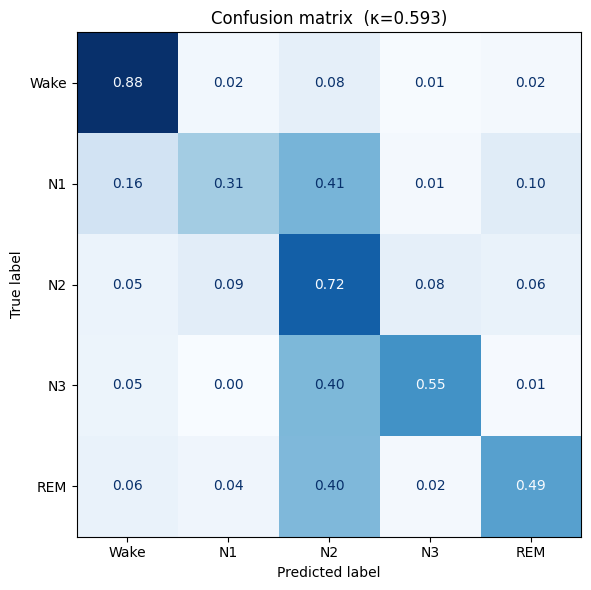

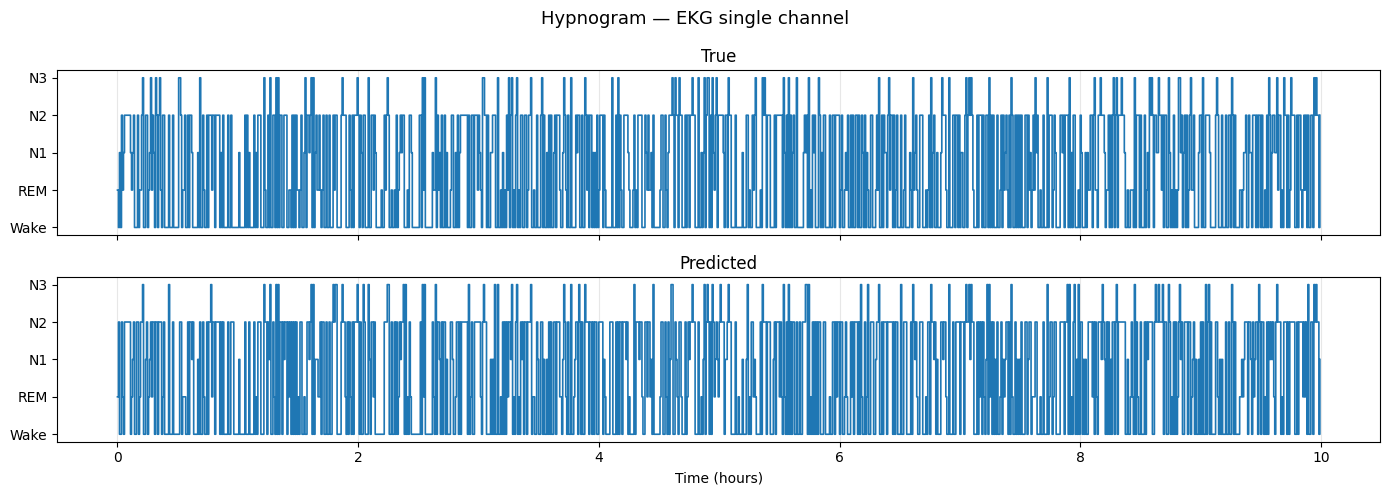

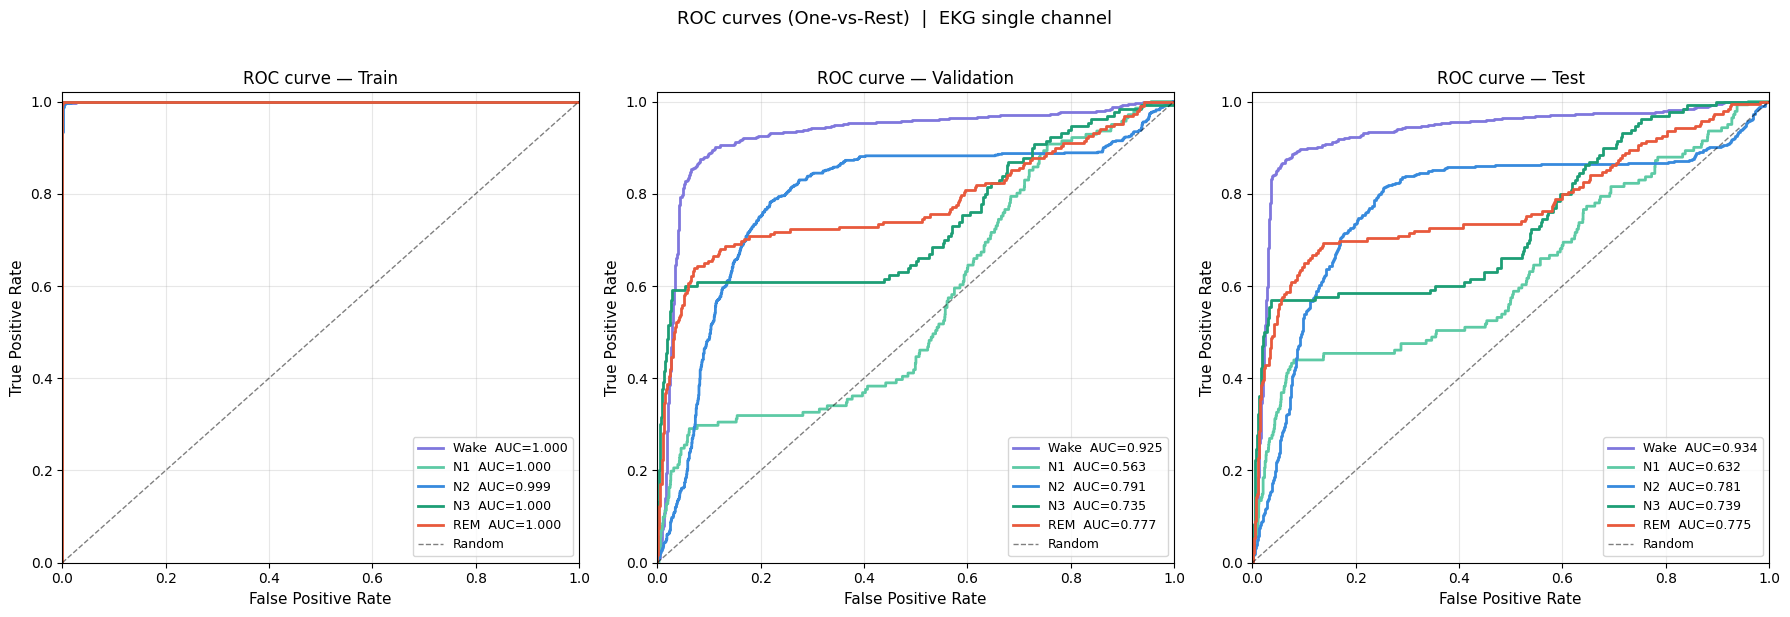


AUC summary:
Class     Train         Validation    Test        
Wake      1.000         0.925         0.934       
N1        1.000         0.563         0.632       
N2        0.999         0.791         0.781       
N3        1.000         0.735         0.739       
REM       1.000         0.777         0.775       


In [ ]:

stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


ckpt = torch.load(SAVE_PATH, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Best model: epoch {ckpt['epoch']}  κ={ckpt['kappa']:.4f}")


def collect_preds(loader):
    """
    Runs model on a DataLoader.
    Returns:
      preds      : (N,)    integer predictions
      true_labels: (N,)    integer ground truth
      probs      : (N, 5)  softmax probabilities
    """
    all_preds, all_true, all_probs = [], [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(device))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_probs.append(probs)
            all_preds.extend(preds)
            all_true.extend(y_b.numpy())
    return (np.array(all_preds),
            np.array(all_true),
            np.concatenate(all_probs, axis=0))



print("\nRunning on test set...")
test_preds, test_true, test_probs   = collect_preds(test_loader)

print("Running on val set...")
val_preds,  val_true,  val_probs    = collect_preds(val_loader)

print("Running on train set...")
train_preds, train_true, train_probs = collect_preds(train_loader)

# ── Test set metrics ──────────────────────────────────────────
acc   = (test_preds == test_true).mean() * 100
kappa = cohen_kappa_score(test_true, test_preds)
print(f"\nTest Accuracy : {acc:.2f}%")
print(f"Cohen's Kappa : {kappa:.4f}")
print()
print(classification_report(test_true, test_preds,
                             target_names=stage_names))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(test_true, test_preds, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=stage_names).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
ax.set_title(f'Confusion matrix  (κ={kappa:.3f})')
plt.tight_layout()
plt.show()

# ── Hypnogram ─────────────────────────────────────────────────
n_show  = min(1200, len(test_true))
remap   = {0:0, 4:1, 1:2, 2:3, 3:4}
ylabels = ['Wake', 'REM', 'N1', 'N2', 'N3']
times   = np.arange(n_show) * 30 / 3600

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, seq, title in [(ax1, test_true[:n_show],  'True'),
                       (ax2, test_preds[:n_show], 'Predicted')]:
    ax.step(times, [remap[s] for s in seq], where='post', lw=1.2)
    ax.set_yticks(range(5))
    ax.set_yticklabels(ylabels)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
ax2.set_xlabel('Time (hours)')
plt.suptitle('Hypnogram — EKG single channel', fontsize=13)
plt.tight_layout()
plt.show()

# ── ROC curves ────────────────────────────────────────────────
# One-vs-Rest ROC for each class, on each split
# Binarize labels: shape (N, 5)
colors = ['#7F77DD', '#5DCAA5', '#378ADD', '#1D9E75', '#E8593C']

splits = [
    ('Train',      train_true, train_probs),
    ('Validation', val_true,   val_probs),
    ('Test',       test_true,  test_probs),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (split_name, y_true, y_probs) in zip(axes, splits):

    # Binarize ground truth: (N, 5)
    y_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

    # Plot one ROC curve per class
    for cls_idx, (cls_name, color) in enumerate(zip(stage_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx],
                                 y_probs[:, cls_idx])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name}  AUC={roc_auc:.3f}')

    # Diagonal reference line (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC curve — {split_name}', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC curves (One-vs-Rest)  |  EKG single channel',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Print AUC summary table ───────────────────────────────────
print("\nAUC summary:")
print(f"{'Class':<8}", end="")
for split_name, _, _ in splits:
    print(f"  {split_name:<12}", end="")
print()

for cls_idx, cls_name in enumerate(stage_names):
    print(f"{cls_name:<8}", end="")
    for _, y_true, y_probs in splits:
        y_bin   = label_binarize(y_true, classes=[0,1,2,3,4])
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], y_probs[:, cls_idx])
        print(f"  {auc(fpr,tpr):.3f}       ", end="")
    print()